<a href="https://colab.research.google.com/github/manas-geo/My-City/blob/main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Extract a Temperature Time-Series

[TerraClimate](https://www.climatologylab.org/terraclimate.html) is long-term climatology dasaset that provides monthly-aggregated gridded data from 1950-present. It is hosted on a THREDDS Data Server (TDS) and served using the OPeNDAP (Open Data Access Protocol) protocol. XArray has built-in support to efficiently read and process OPeNDAP data where we can stream and process only the required pixels without downloading entire dataset.

Your task is to access the TerraClimate Monthly Maximum Temperature dataset and extract a time-series showing the temperatures at your chosen location from 1970-2025.

![](https://courses.spatialthoughts.com/images/python_remote_sensing/terraclimate.png)

Notes:

* Explore the [TerraClimate Catalog](http://thredds.northwestknowledge.net:8080/thredds/terraclimate_aggregated.html) on the THREDDS Data Server for all available datasets. This notebook providers code snippets below to show the access pattern.
* Use XArray's indexing methods to select the required subset from 1970-2025.


Make sure to install the `netCDF4` package for XArray to access NetCDF format data.

In [ ]:
!pip install netCDF4

Import all required libraries.

In [ ]:
terraclimate_url = 'http://thredds.northwestknowledge.net:8080/thredds/dodsC/'
variable = 'tmax'
filename = f'agg_terraclimate_{variable}_1950_CurrentYear_GLOBE.nc'
remote_file_path = os.path.join(terraclimate_url, filename)
ds = xr.open_dataset(
    remote_file_path,
    chunks='auto',
    engine='netcdf4',
)
ds

#Solution

#Step 1: Install and Import Required Libraries

In [1]:
%%capture
!pip install -q netCDF4 xarray matplotlib dask[distributed] bokeh

In [2]:
import os
import warnings
import logging
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dask.distributed import Client
from google.colab import output

# Suppress warnings and verbose logs for a clean output
logging.getLogger("distributed").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)

# Close any old clients and start a fresh one
try:
    client.close()
except NameError:
    pass
client = Client()

warnings.filterwarnings("default", category=UserWarning)

# Embed the Dask Dashboard directly in the Colab output
dashboard_port = client.scheduler_info()['services']['dashboard']
print(f"Dask Dashboard is running:")
output.serve_kernel_port_as_iframe(dashboard_port, height=800)

Dask Dashboard is running:


<IPython.core.display.Javascript object>

#Step 2: Connect to the TerraClimate OPeNDAP Server

In [3]:
# Define the URL and target file
terraclimate_url = 'http://thredds.northwestknowledge.net:8080/thredds/dodsC/'
variable = 'tmax'
filename = f'agg_terraclimate_{variable}_1950_CurrentYear_GLOBE.nc'
remote_file_path = os.path.join(terraclimate_url, filename)

# Open the remote dataset lazily over the network
ds = xr.open_dataset(
    remote_file_path,
    chunks='auto',
    engine='netcdf4'
)

print("Successfully connected to the dataset!")

Successfully connected to the dataset!


#Step 3: Select Location and Extract Time-Series

In [4]:
%%time
from dask.distributed import progress

# 1. Define coordinates for Dhanbad, Jharkhand
target_lat = 23.79
target_lon = 86.43

# 2. Extract spatial pixel first, THEN slice time
lazy_ts_data = ds[variable].sel(
    lat=target_lat,
    lon=target_lon,
    method='nearest'
).sel(
    time=slice('1970-01-01', '2025-12-31')
)

print("-> Dashboard: Scroll up to see the status of dask dashboard.")
print("-> Cell Output:\n")

# 3. Submit the computation to your active Dashboard
future = client.compute(lazy_ts_data)

# 4. Print a task percentage
progress(future, notebook=False)

# 5. Pull the data into memory
ts_data = future.result()

print(f"\nExtraction complete! Found {len(ts_data.time)} months of records.")

-> Dashboard: Scroll up to see the status of dask dashboard.
-> Cell Output:


Extraction complete! Found 672 months of records.
CPU times: user 9.78 s, sys: 1.47 s, total: 11.2 s
Wall time: 2min 25s


#Step 4: Plot the Data

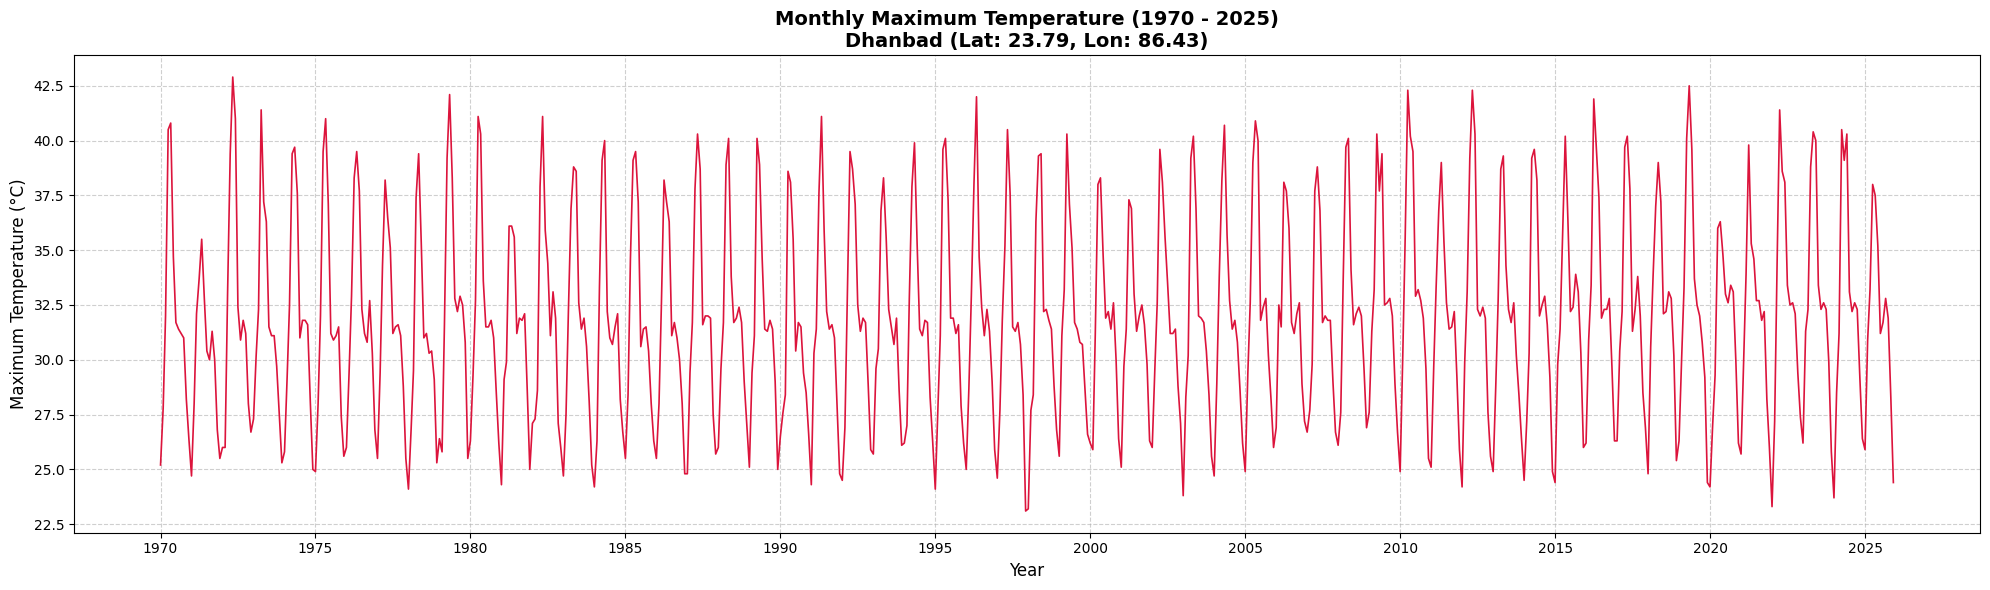

In [5]:
# Initialize a clear, wide figure
import matplotlib.dates as mdates
plt.figure(figsize=(20, 6))

# Plot the 55-year time-series
ts_data.plot(color='crimson', linewidth=1.2)

# Add informative titles and labels
plt.title(f'Monthly Maximum Temperature (1970 - 2025)\nDhanbad (Lat: {target_lat}, Lon: {target_lon})', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Maximum Temperature (°C)', fontsize=12)

# Format the X-axis for 5-year intervals
ax = plt.gca()  # Get the current axis
ax.xaxis.set_major_locator(mdates.YearLocator(5))  # Set major ticks every 5 years
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format labels to show only the year

# Add gridlines to make tracking trends easier
plt.grid(True, linestyle='--', alpha=0.6)

# Render the plot
plt.tight_layout()
plt.show()

##Step 5: Shut down the dask

In [6]:
client.close()
print("Dask cluster safely shut down.")

Dask cluster safely shut down.
